In [11]:
import sys
import os

project_root = r"C:\Users\User\Documents\GitHub\predictive-maintenance"
src_path = os.path.join(project_root, "src")
data_path = os.path.join(project_root, "data")

sys.path.append(src_path)
from data_loader import load_cmapss, add_rul_labels

train, test, rul = load_cmapss(
    os.path.join(data_path, "train_FD001.txt"),
    os.path.join(data_path, "test_FD001.txt"),
    os.path.join(data_path, "RUL_FD001.txt"),
)
train = add_rul_labels(train)
train.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [12]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL shape:", rul.shape)
print("Train units:", train['unit_number'].nunique())

Train shape: (20631, 27)
Test shape: (13096, 26)
RUL shape: (100, 1)
Train units: 100


Matplotlib is building the font cache; this may take a moment.


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


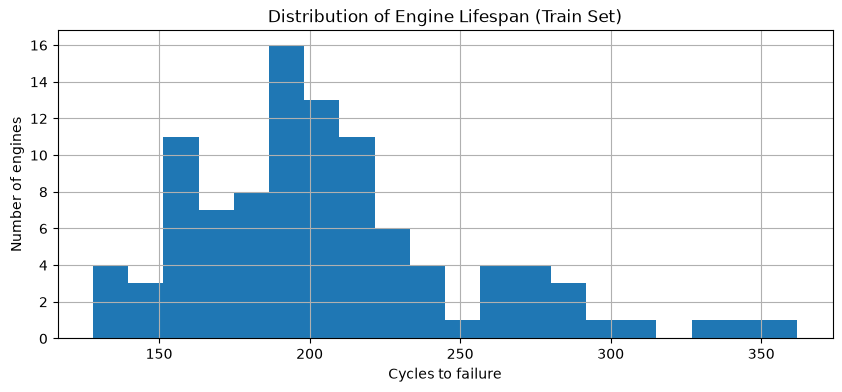

In [13]:
import matplotlib.pyplot as plt

# How many cycles did each engine run before failure?
max_cycles = train.groupby('unit_number')['time_in_cycles'].max()
print(max_cycles.describe())

plt.figure(figsize=(10, 4))
max_cycles.hist(bins=20)
plt.xlabel("Cycles to failure")
plt.ylabel("Number of engines")
plt.title("Distribution of Engine Lifespan (Train Set)")
plt.show()

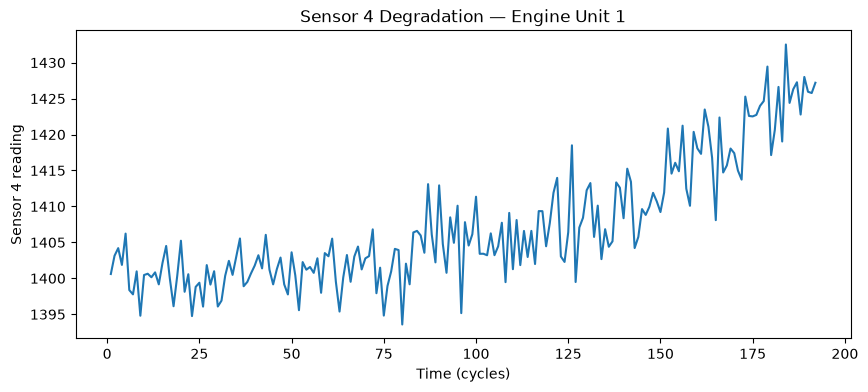

In [14]:
# Pick one engine and look at a sensor over its lifetime
unit1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10, 4))
plt.plot(unit1['time_in_cycles'], unit1['sensor_4'])
plt.xlabel("Time (cycles)")
plt.ylabel("Sensor 4 reading")
plt.title("Sensor 4 Degradation — Engine Unit 1")
plt.show()

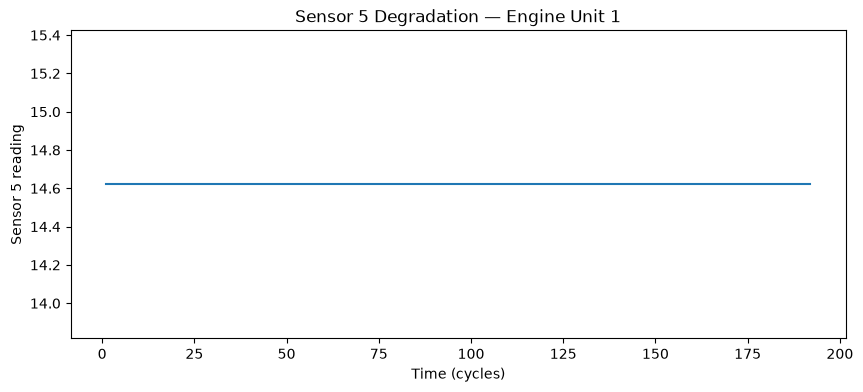

In [15]:
# Pick one engine and look at a sensor over its lifetime
unit1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10, 4))
plt.plot(unit1['time_in_cycles'], unit1['sensor_5'])
plt.xlabel("Time (cycles)")
plt.ylabel("Sensor 5 reading")
plt.title("Sensor 5 Degradation — Engine Unit 1")
plt.show()

In [16]:
# Check variance of each sensor - flat sensors will have ~0 variance
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_variance = train[sensor_cols].var().sort_values()
print(sensor_variance)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


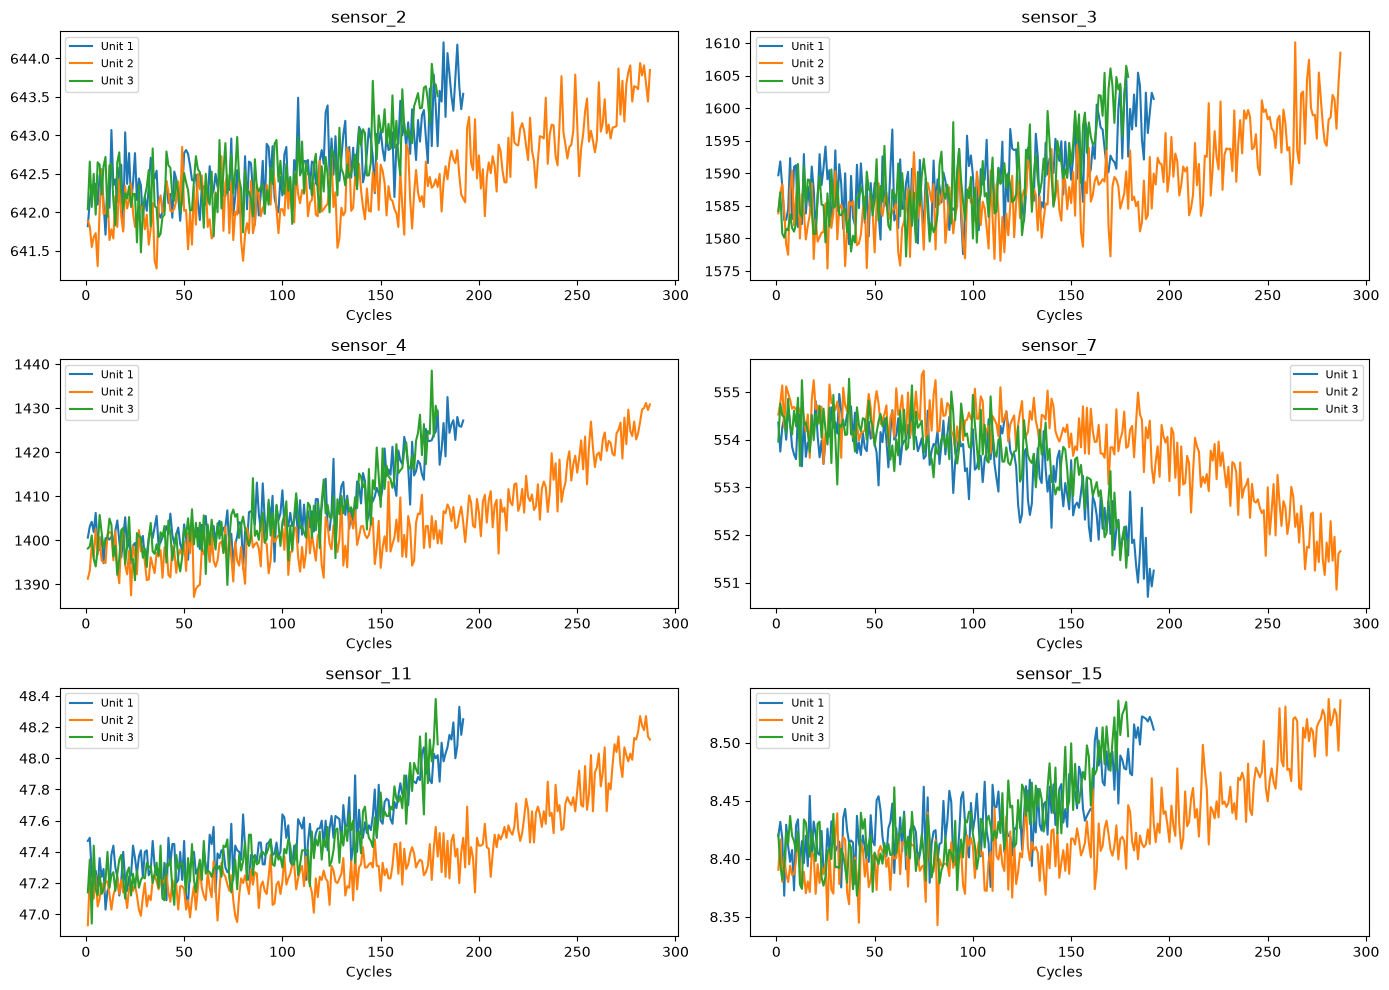

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
sensors_to_check = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

for ax, sensor in zip(axes.flat, sensors_to_check):
    for unit in [1, 2, 3]:  # look at first 3 engines
        unit_data = train[train['unit_number'] == unit]
        ax.plot(unit_data['time_in_cycles'], unit_data[sensor], label=f'Unit {unit}')
    ax.set_title(sensor)
    ax.set_xlabel('Cycles')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# Sensors with clear degradation trends (based on EDA)
informative_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

# Confirm variance is meaningfully non-zero for these vs. the flat ones
print(train[informative_sensors + ['sensor_5']].var())

sensor_2     2.500533e-01
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_7     7.833883e-01
sensor_11    7.133568e-02
sensor_15    1.406628e-03
sensor_5     2.840037e-29
dtype: float64


In [19]:
feature_cols = informative_sensors
X = train[feature_cols]
y = train['RUL']

print(X.shape, y.shape)
X.head()

(20631, 6) (20631,)


,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15
0,641.82,1589.70,1400.60,554.36,47.47,8.4195
1,642.15,1591.82,1403.14,553.75,47.49,8.4318
2,642.35,1587.99,1404.20,554.26,47.27,8.4178
3,642.35,1582.79,1401.87,554.45,47.13,8.3682
4,642.37,1582.85,1406.22,554.00,47.28,8.4294


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Split into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline model: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"Baseline Linear Regression — RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Baseline Linear Regression — RMSE: 46.07, MAE: 35.47


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf = mean_absolute_error(y_val, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}")

Random Forest — RMSE: 45.84, MAE: 34.34


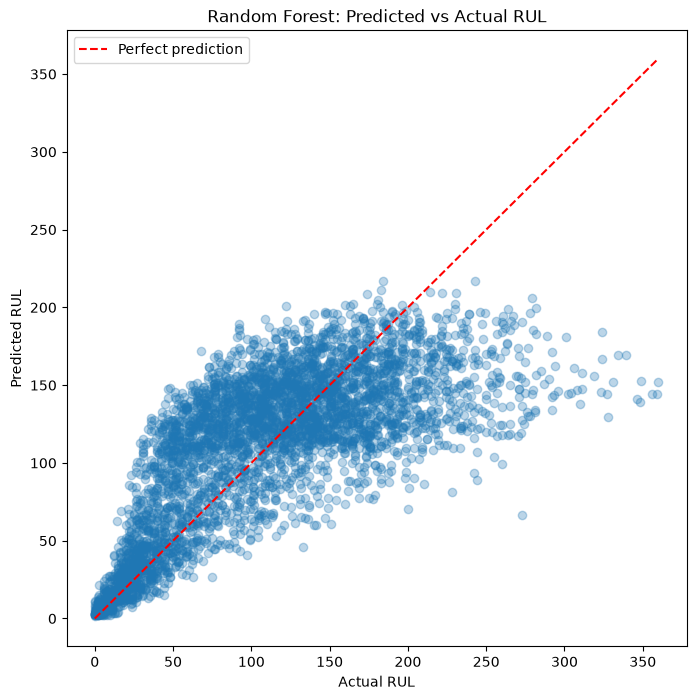

In [22]:
plt.figure(figsize=(8, 8))
plt.scatter(y_val, y_pred_rf, alpha=0.3)
plt.plot([0, y_val.max()], [0, y_val.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Predicted vs Actual RUL")
plt.legend()
plt.show()

In [23]:
# Add rolling mean features (window of 5 cycles) for each informative sensor
window = 5

for sensor in informative_sensors:
    train[f'{sensor}_rollmean'] = (
        train.groupby('unit_number')[sensor]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

rolling_cols = [f'{s}_rollmean' for s in informative_sensors]
print(train[rolling_cols].head(10))

   sensor_2_rollmean  sensor_3_rollmean  sensor_4_rollmean  sensor_7_rollmean  \
0         641.820000        1589.700000        1400.600000         554.360000   
1         641.985000        1590.760000        1401.870000         554.055000   
2         642.106667        1589.836667        1402.646667         554.123333   
3         642.167500        1588.075000        1402.452500         554.205000   
4         642.208000        1587.030000        1403.206000         554.164000   
5         642.264000        1585.984000        1402.760000         554.226000   
6         642.330000        1586.084000        1401.686000         554.344000   
7         642.372000        1585.078000        1401.040000         554.262000   
8         642.326000        1586.716000        1399.626000         554.110000   
9         642.194000        1588.394000        1398.474000         554.028000   

   sensor_11_rollmean  sensor_15_rollmean  
0              47.470            8.419500  
1              47.48

In [24]:
feature_cols_v2 = informative_sensors + rolling_cols
X2 = train[feature_cols_v2]
y2 = train['RUL']

X_train2, X_val2, y_train2, y_val2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf_model2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model2.fit(X_train2, y_train2)

y_pred_rf2 = rf_model2.predict(X_val2)
rmse_rf2 = np.sqrt(mean_squared_error(y_val2, y_pred_rf2))
mae_rf2 = mean_absolute_error(y_val2, y_pred_rf2)

print(f"Random Forest + Rolling Features — RMSE: {rmse_rf2:.2f}, MAE: {mae_rf2:.2f}")

Random Forest + Rolling Features — RMSE: 43.70, MAE: 32.27


In [28]:
import pandas as pd

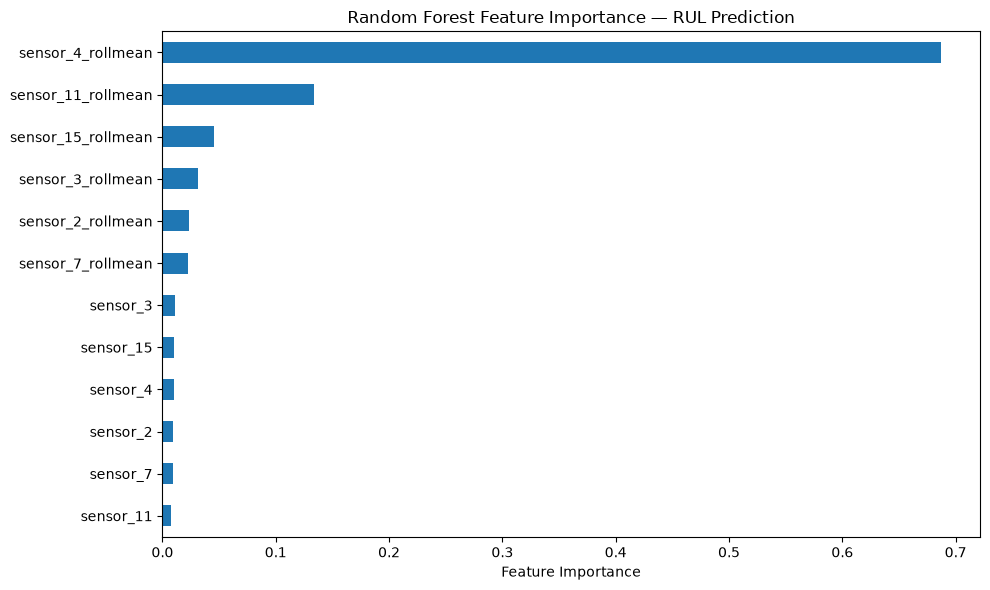

sensor_4_rollmean     0.687129
sensor_11_rollmean    0.133426
sensor_15_rollmean    0.045279
sensor_3_rollmean     0.031729
sensor_2_rollmean     0.023024
sensor_7_rollmean     0.022385
sensor_3              0.010726
sensor_15             0.010133
sensor_4              0.010090
sensor_2              0.009417
sensor_7              0.009028
sensor_11             0.007634
dtype: float64


In [29]:
importances = pd.Series(rf_model2.feature_importances_, index=feature_cols_v2)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance — RUL Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/feature_importance.png'

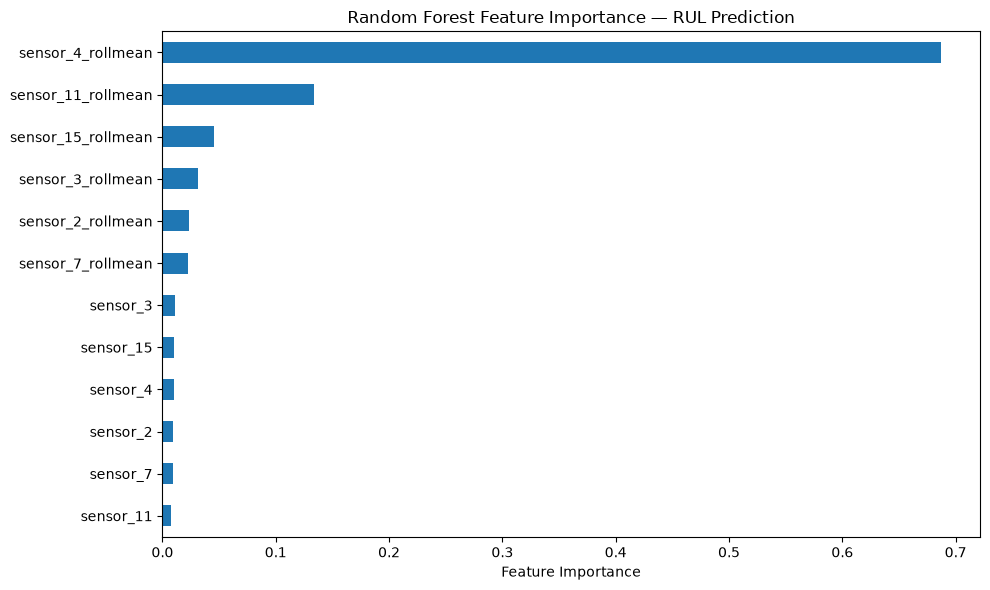

In [30]:
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance — RUL Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import os
print(os.getcwd())
print(os.path.exists("../outputs"))

C:\Users\User\Documents\GitHub\predictive-maintenance
False


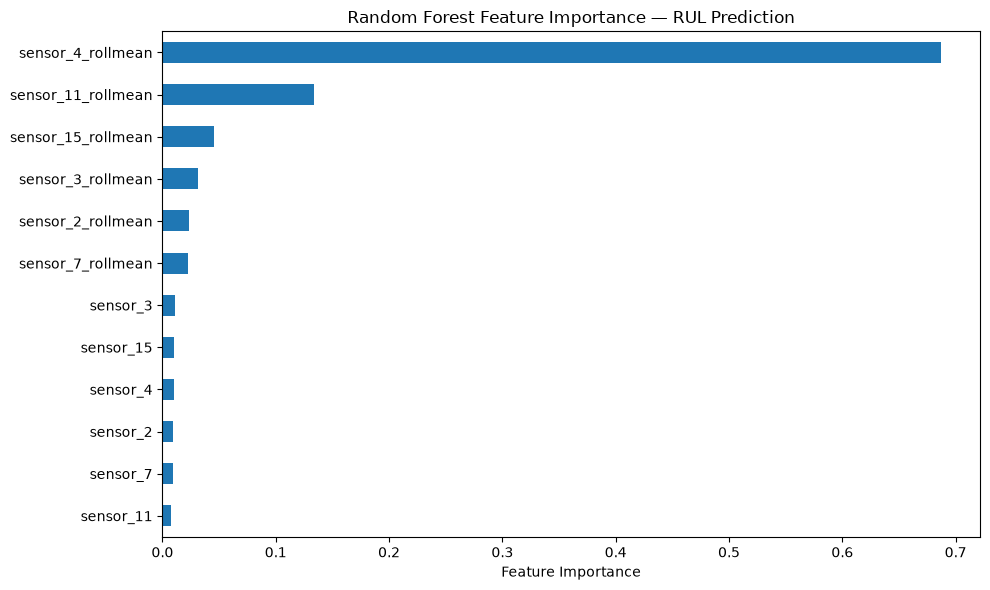

In [32]:
import os

project_root = r"C:\Users\User\Documents\GitHub\predictive-maintenance"
outputs_path = os.path.join(project_root, "outputs")
os.makedirs(outputs_path, exist_ok=True)  # creates it if missing, no error if it exists

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance — RUL Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, "feature_importance.png"), dpi=150, bbox_inches='tight')
plt.show()

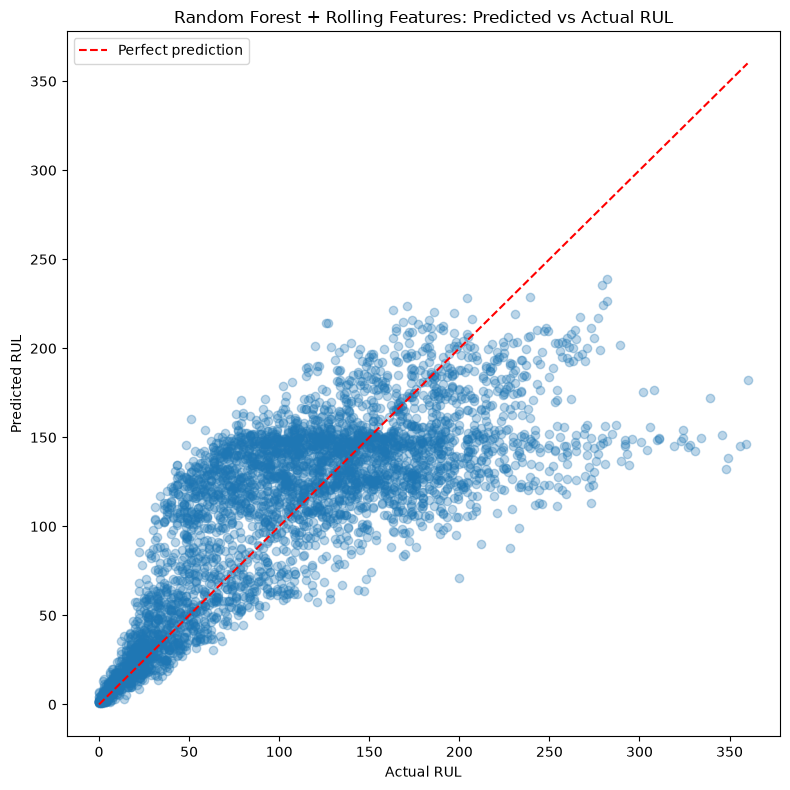

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(y_val2, y_pred_rf2, alpha=0.3)
plt.plot([0, y_val2.max()], [0, y_val2.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest + Rolling Features: Predicted vs Actual RUL")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, "predicted_vs_actual.png"), dpi=150, bbox_inches='tight')
plt.show()

In [34]:
![Feature Importance](outputs/feature_importance.png)
   ![Predicted vs Actual RUL](outputs/predicted_vs_actual.png)

IndentationError: unexpected indent (2562412617.py, line 2)